# Support Ticket Classification & Prioritization
This notebook covers Data Preprocessing, EDA, Model Training, and Evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
import re
import string
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

## 1. Data Preprocessing

In [2]:
# Download NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Load data
df = pd.read_csv('../dataset/support_tickets.csv')
print("Shape before cleaning:", df.shape)

# Handle missing values
df = df.dropna(subset=['Ticket Description'])

# Remove duplicates
df = df.drop_duplicates(subset=['Ticket Description'])
print("Shape after cleaning:", df.shape)

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)
    # Tokenization
    tokens = nltk.word_tokenize(text)
    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

df['Clean_Description'] = df['Ticket Description'].apply(preprocess_text)
df.head()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\macha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\macha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\macha\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Shape before cleaning: (2060, 5)
Shape after cleaning: (716, 5)


,Ticket ID,Ticket Description,Category,Priority Level,Date Created,Clean_Description
0,TKT-1575,Please help. I want to cancel my subscription ...,Billing Issues,High,2025-09-09 15:04:11,please help want cancel subscription need know...
2,TKT-2228,ASAP. I was charged twice for my subscription ...,Billing Issues,High,2026-05-29 15:04:11,asap charged twice subscription month thanks
3,TKT-1020,Are there any discounts available for students...,Product Inquiry,Low,2026-03-31 15:04:11,discounts available students nonprofits
4,TKT-2495,Urgent! My data is not syncing across devices.,Technical Issues,Medium,2025-09-11 15:04:11,urgent data syncing across devices
5,TKT-1770,"Is the platform compliant with GDPR? Hello,",Product Inquiry,Low,2025-10-24 15:04:11,platform compliant gdpr hello


## 2. Exploratory Data Analysis

C:\Users\macha\AppData\Local\Temp\ipykernel_29272\1304674951.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Category', palette='viridis', order=df['Category'].value_counts().index)


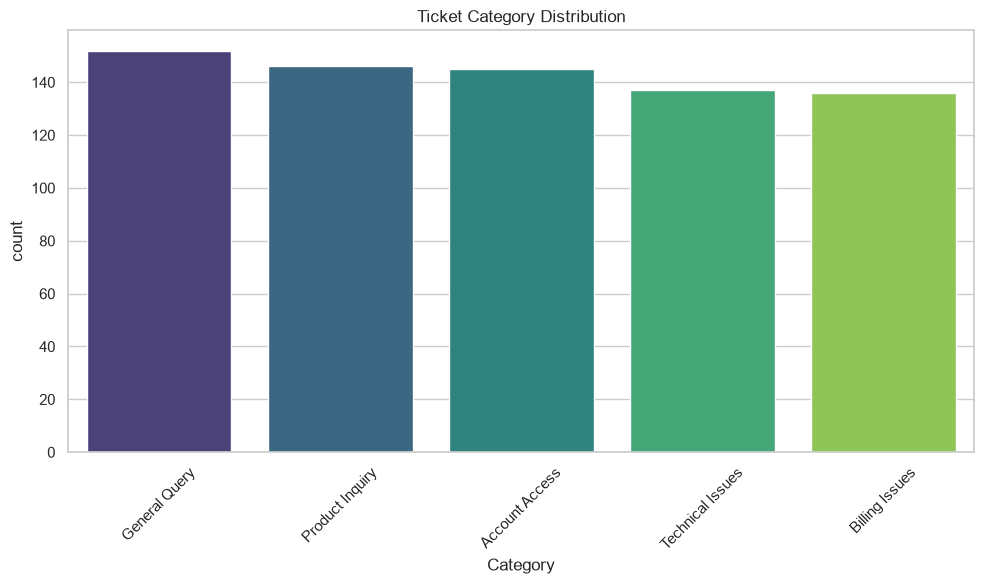

C:\Users\macha\AppData\Local\Temp\ipykernel_29272\1304674951.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Priority Level', palette='magma', order=['High', 'Medium', 'Low'])


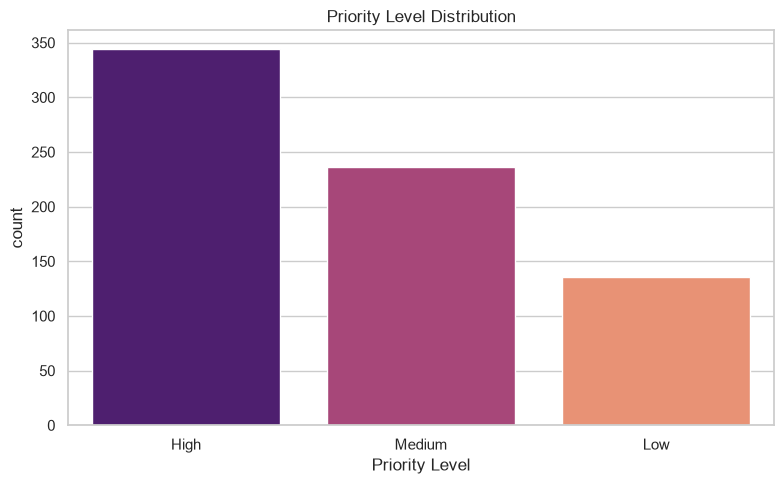

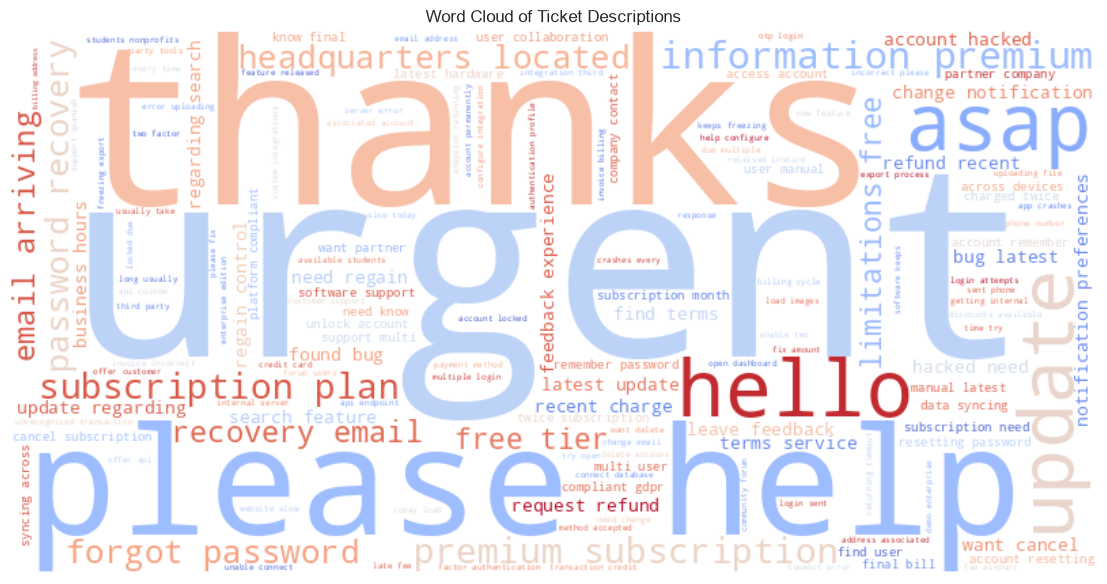

In [3]:
# Set visualization style
sns.set(style="whitegrid")
os.makedirs('../images', exist_ok=True)

# 1. Ticket Category Distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Category', palette='viridis', order=df['Category'].value_counts().index)
plt.title("Ticket Category Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../images/category_distribution.png')
plt.show()

# 2. Priority Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Priority Level', palette='magma', order=['High', 'Medium', 'Low'])
plt.title("Priority Level Distribution")
plt.tight_layout()
plt.savefig('../images/priority_distribution.png')
plt.show()

# 3. Word Cloud
all_words = " ".join(df['Clean_Description'])
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='coolwarm').generate(all_words)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Ticket Descriptions")
plt.tight_layout()
plt.savefig('../images/wordcloud.png')
plt.show()

## 3. Feature Engineering & Modeling for Category Classification

Logistic Regression Accuracy: 1.0000
Naive Bayes Accuracy: 1.0000
Random Forest Accuracy: 1.0000
Best Category Model: LogisticRegression(max_iter=1000)
                  precision    recall  f1-score   support

  Account Access       1.00      1.00      1.00        27
  Billing Issues       1.00      1.00      1.00        28
   General Query       1.00      1.00      1.00        35
 Product Inquiry       1.00      1.00      1.00        27
Technical Issues       1.00      1.00      1.00        27

        accuracy                           1.00       144
       macro avg       1.00      1.00      1.00       144
    weighted avg       1.00      1.00      1.00       144



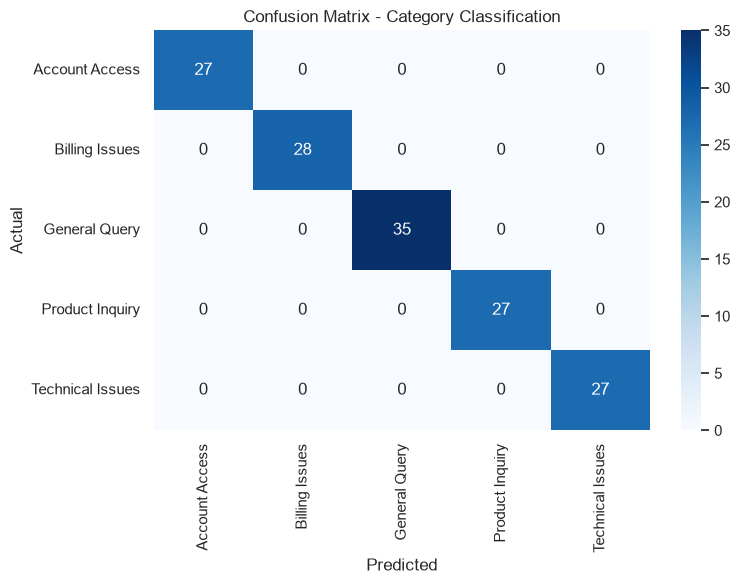

In [4]:
# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['Clean_Description'])
y_category = df['Category']

# Split Data
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_category, test_size=0.2, random_state=42)

# Models
models_cat = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

best_acc = 0
best_model_cat = None

for name, model in models_cat.items():
    model.fit(X_train_c, y_train_c)
    preds = model.predict(X_test_c)
    acc = accuracy_score(y_test_c, preds)
    print(f"{name} Accuracy: {acc:.4f}")
    if acc > best_acc:
        best_acc = acc
        best_model_cat = model

print("Best Category Model:", best_model_cat)

# Evaluation
y_pred_c = best_model_cat.predict(X_test_c)
print(classification_report(y_test_c, y_pred_c))

# Confusion Matrix
cm = confusion_matrix(y_test_c, y_pred_c)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=best_model_cat.classes_, yticklabels=best_model_cat.classes_)
plt.title("Confusion Matrix - Category Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig('../images/confusion_matrix.png')
plt.show()

## 4. Feature Engineering & Modeling for Priority Prediction

In [5]:
y_priority = df['Priority Level']
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X, y_priority, test_size=0.2, random_state=42)

models_pri = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

best_acc_p = 0
best_model_pri = None

for name, model in models_pri.items():
    model.fit(X_train_p, y_train_p)
    preds = model.predict(X_test_p)
    acc = accuracy_score(y_test_p, preds)
    print(f"{name} Accuracy: {acc:.4f}")
    if acc > best_acc_p:
        best_acc_p = acc
        best_model_pri = model

print("Best Priority Model:", best_model_pri)
y_pred_p = best_model_pri.predict(X_test_p)
print(classification_report(y_test_p, y_pred_p))

Logistic Regression Accuracy: 0.5972


Random Forest Accuracy: 0.5417
Best Priority Model: LogisticRegression(max_iter=1000)
              precision    recall  f1-score   support

        High       0.68      0.80      0.73        76
         Low       0.78      0.50      0.61        28
      Medium       0.31      0.28      0.29        40

    accuracy                           0.60       144
   macro avg       0.59      0.53      0.54       144
weighted avg       0.59      0.60      0.59       144



## 5. Export Models

In [6]:
os.makedirs('../models', exist_ok=True)
joblib.dump(vectorizer, '../models/tfidf_vectorizer.pkl')
joblib.dump(best_model_cat, '../models/category_model.pkl')
joblib.dump(best_model_pri, '../models/priority_model.pkl')
print("Models exported successfully!")

Models exported successfully!
